# Data Processing and Vizualisation REPORT
## BSc Informatique et Syèstemes de Communication (ISC) vs BSc Informatique de Gestion (IDG)
### Compare the text contents of two different bachelor courses from the same university
James Zeiger\
ID: 11\
Nbr: 25\
Subject: BSc Inf. D gestion

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import nltk
# nltk.download('punkt')
# nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

from wordcloud import WordCloud

from nltk.stem import SnowballStemmer

The two text files below contain all the words on both the ISC and IDG official website, by simply selecting all (Ctrl+A) and copy pasting it to a blank .txt file.

In [68]:
# Read a file
text1_1 = Path("res/website-full.txt").read_text()
text2_1 = Path("res/my_website_full.txt").read_text()

## Generic info
To start, we keep things simple by extracting the amount of words, sentences and unique words.

This simple task may seem simple at first, but to extract the amount of sentences is more difficult than we might think.\
Thanks to the `Natural Language Toolkit (nltk)`, which is a library specialized in human language data processing, we can just apply the pre-made functions we need.

ISC
Number of words:         1775
Number of sentences:     51
Number of unique words:  704
------------------------------
IDG
Number of words:         1857
Number of sentences:     53
Number of unique words:  800


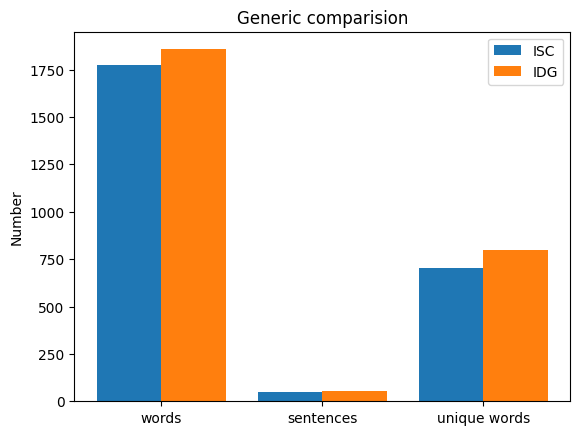

In [69]:
w1        = word_tokenize(text1_1)
w2        = word_tokenize(text2_1)
nbr_w1    = len(w1)
nbr_w2    = len(w2)
nbr_sen1  = len(sent_tokenize(text1_1))
nbr_sen2  = len(sent_tokenize(text2_1))
nbr_uw1   = len(set(w1))
nbr_uw2   = len(set(w2))

print("ISC")
print("Number of words:        ", nbr_w1)
print("Number of sentences:    ", nbr_sen1)
print("Number of unique words: ", nbr_uw1)

print("------------------------------")
print("IDG")
print("Number of words:        ", nbr_w2)
print("Number of sentences:    ", nbr_sen2)
print("Number of unique words: ", nbr_uw2)

x_names = np.array(["words", "sentences", "unique words"])
d1 = [nbr_w1, nbr_sen1, nbr_uw1]
d2 = [nbr_w2, nbr_sen2, nbr_uw2]

w, x = 0.4, np.arange(len(x_names))
fig, ax = plt.subplots()
ax.bar(x - w/2, d1, width=w, label='ISC')
ax.bar(x + w/2, d2, width=w, label='IDG')

ax.set_xticks(x)
ax.set_xticklabels(x_names)
ax.set_ylabel('Number')
ax.set_title('Generic comparision')
ax.legend()
plt.show()


We can observe the raw text distribution of both websites and we could almost say that they are similar.\
The IDG's website has 82 more words than ISC but only two more sentences. This could mean that IDG has some very long sentences and would be worth reviewing.

However, for the 82 word increase, there is still a large unique word gap of 96. This could mean that ISC has a lot of repetition, possibly being `filler-words` or `stop-words`.

We could hypothesize that the ISG's website contains long sentences and ISC's website conatains a few too many long repetitive words.\
To coninue, it is difficult to come to any reliable conclusion due to the "useless" or irrelevent words. This is where pre-processing comes in to play.

# Pre-Processing

Here we are going through the first process of word filtering, which is the removal of stop-words.\
This will help us extract the key words that aren't simply the most frequent and uninformative, such as `I, was, the, it`.

When reading the websites, we can see that there are french words contained in addresses for example and other similar occurences. They are in french even if the page language is english, so we must also remove the french stop-words.

The removal of punctiation is also necessary for the same reasons. We can take the `@` or `&` symboles as example.

English stop-words: `stopwords.words('english')`\
French stop-words:  `stopwords.words('french')`\
Punctuation: `list(string.punctuation)` that contains !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~ which are very commun and therefor usefull to remove.

All together we filter useless words, when it comes to pure word and unique word count and content classification.

The code below removes all 3 points mentionned above.

In [70]:
def filter_words(text):
  stop_words = set(stopwords.words('english') + stopwords.words('french') + list(string.punctuation))
  word_tokens = word_tokenize(text)

  # no stop words
  filtered_text = [w for w in word_tokens if not w.lower() in stop_words]

  return filtered_text

# create new filtered text without punctuation or filler words
with open("res/website_filtered.txt", "w") as f:
  for word in filter_words(text1_1):
    f.write(word + " ")
with open("res/my_website_filtered.txt", "w") as f:
  for word in filter_words(text2_1):
    f.write(word + " ")


nbr_w1  = len(filter_words(text1_1))
nbr_w2  = len(filter_words(text2_1))
nbr_uw1 = len(set(filter_words(text1_1)))
nbr_uw2 = len(set(filter_words(text2_1)))


# write to .txt file
text1_2 = Path("res/website_filtered.txt").read_text()
text2_2 = Path("res/my_website_filtered.txt").read_text()

We now have two new filtered text files, on which we will continue our analysis.

Percentage of words pruned due to filtering:
ISC: 43.83% | IDG: 36.35%

How many duplicate non-stop-words:
ISC: 778 | IDG: 675


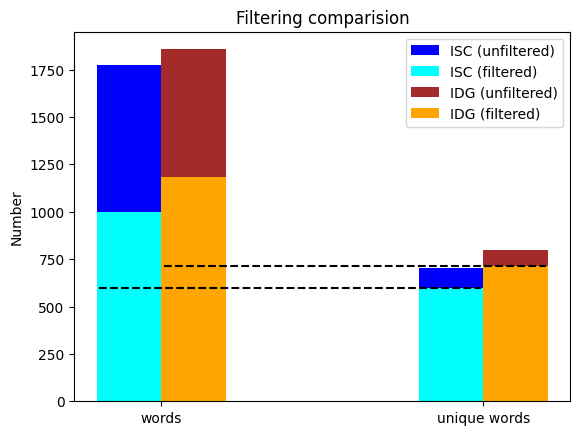

In [71]:
d1_1 = [d1[0], d1[2]]
d2_1 = [d2[0], d2[2]]
d1_2 = [nbr_w1, nbr_uw1]
d2_2 = [nbr_w2, nbr_uw2]

print(f"Percentage of words pruned due to filtering:\nISC: {round(100-d1_2[0]/d1_1[0]*100, 2)}% | IDG: {round(100-d2_2[0]/d2_1[0]*100, 2)}%\n")
print(f"How many duplicate non-stop-words:\nISC: {d1_1[0]-d1_2[0]} | IDG: {d2_1[0]-d2_2[0]}")

x_names = np.array(["words", "unique words"])
w, x = 0.2, np.arange(len(x_names))
fig, ax = plt.subplots()
ax.bar(x - w/2, d1_1, width=w, label='ISC (unfiltered)', color='blue')
ax.bar(x - w/2, d1_2, width=w, label='ISC (filtered)', color='cyan')
ax.bar(x + w/2, d2_1, width=w, label='IDG (unfiltered)', color='brown')
ax.bar(x + w/2, d2_2, width=w, label='IDG (filtered)', color='orange')

ax.axhline(y=d1_2[1], color='black', linestyle='--', xmin=0.05, xmax=0.82)
ax.axhline(y=d2_2[1], color='black', linestyle='--', xmin=0.18, xmax=0.95)

ax.set_xticks(x)
ax.set_xticklabels(x_names)
ax.set_ylabel('Number')
ax.set_title('Filtering comparision')
ax.legend()
plt.show()

By simply cleaning up the filler words, we can see that both's number of words have greatly reduced, but ISC's in particular. This clearly means that there is a lot of uninteresting text due to the amount of stop-words.

IDG's word count may be higher, but there are already signs of it containing more interesting and perhaps even subject orientated words. We can come to this conclusion, because fewer words were pruned and it's unique word count reduced less than ISC's.

We can also see with the dotted lines, the cut-off of unique words against the filtered words. For ISC, it's about 30-35% of the words left are duplicates and close to 40% for IDG.\
This statistic is important, because now we are dealing with key words that will be able to determine the overall context of each website.\
A good way to visualize these contents is with a wordcloud.

## Wordcloud
`Why it's usefull`\
This form of vizualisation determines whether or not the website contains the key words people are looking for.
A university course website should primarily contain words associated with its subject.

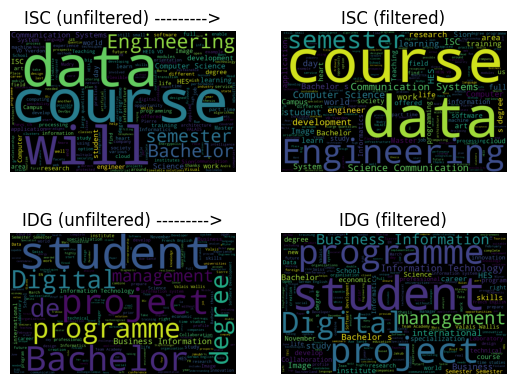

In [72]:
wordcloud1_1 = WordCloud(width=800, height=500).generate(text1_1)
wordcloud1_2 = WordCloud(width=800, height=500).generate(text1_2)
wordcloud2_1 = WordCloud(width=800, height=500).generate(text2_1)
wordcloud2_2 = WordCloud(width=800, height=500).generate(text2_2)

fig, axarr = plt.subplots(2,2)
axarr[0,0].imshow(wordcloud1_1)
axarr[0,0].axis("off")
axarr[0,0].set_title("ISC (unfiltered) --------->")

axarr[0,1].imshow(wordcloud1_2)
axarr[0,1].axis("off")
axarr[0,1].set_title("ISC (filtered)")


axarr[1,0].imshow(wordcloud2_1)
axarr[1,0].axis("off")
axarr[1,0].set_title("IDG (unfiltered) --------->")

axarr[1,1].imshow(wordcloud2_2)
axarr[1,1].axis("off")
axarr[1,1].set_title('IDG (filtered)')
plt.show()

In wordclouds, the more a certain word appears in a selected text, the larger it will a apear in the the final image.

There are two goals that are looking to be acomplished using wordclouds. 
1. observe the effective removal of stop words in both languages
2. observe the most frequent words per website

We can see the unfiltered text wordclouds on the left versus the filtered on the right.\
Already the stop-word "will" is completely removed which is a good sign.\
When looking at the filtered graphs, the biggest words are all relevent to each course.

ISC should contain at the bear minimum: `Informatique (or computer science), communication and data` since these are the absolute key words. It does a good job with `data` since this is the course's orientation. When looking at the slightly smaller words, all the relevent ones appear, so this site contains, in my opinion all the correct main words.

For IDG it should contain: `Informatique (or computer science), management, project`. It also does a good job having two of the major key words amongst the biggest, but student being the most occuring word may show some point to some rephrasing neccesities.


Now let's see if we can further enhance the visualization of the filtered text's content with the help of stemming.

# Data cleaning
# Stemming
With all the data pre-processed, removing stop-words and punctuation, we can now attempt to enhance the current texts to better understand and/or visualize it's content.

Stemming helps reduce words of the same familiy to one common word that helps narrow down the data further.\
For example if a text contains "Shoes run shoes running shoes ran shoes runner shoes runners shoes", there will be one giant "shoes" word and 5 small running orientated words.

If we stem the same text, we will get shoes and all the running words are reduced to "run".

So we do the same on our two sites.

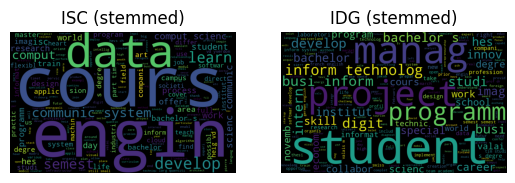

In [73]:
stemmer = SnowballStemmer(language='english')

w1_to_stem = text1_2.split(" ")
w2_to_stem = text2_2.split(" ")

stemmed_w1 = [stemmer.stem(word) for word in w1_to_stem]
stemmed_w2 = [stemmer.stem(word) for word in w2_to_stem]

stemmed_text1 = ""
stemmed_text2 = ""
for word in stemmed_w1:
    stemmed_text1 += word + " "
for word in stemmed_w2:
    stemmed_text2 += word + " "

wordcloud1 = WordCloud(width=800, height=500).generate(stemmed_text1)
wordcloud2 = WordCloud(width=800, height=500).generate(stemmed_text2)

fig, axarr = plt.subplots(1,2)
axarr[0].imshow(wordcloud1)
axarr[0].axis("off")
axarr[0].set_title("ISC (stemmed)")

axarr[1].imshow(wordcloud2)
axarr[1].axis("off")
axarr[1].set_title("IDG (stemmed)")
plt.show()

We can see that the wordclouds have changed compared to the previous ones, mainly in the fact that there are a greater number of "readable" words, which means that the stemming worked as intended. The closer words became one and the completly irrelavent words became too small to read.

# Conclusion
In conclusion, we have observed many interresting properties of both websites through this lab and have learned the basics of text processing.

So the improvements to give to the ISC site in comparision to the IDG's are:
- Remove the number of stop-words
- Try to insert a couple more interesting subject orientated words to bring out the computer science and communication traits

And what it did well:
- It kept it's sentences relatively short compared to IDG's
- It's number of words was also shorter

Both are important because the welcome page should be rich on consise.

IDG's unique words were very good, as we can see in the uniformity of it's wordclouds, with it's only problem being the length of it's sentences.